In [1]:
import pandas as pd
import os
import numpy as np
import csv
import matplotlib.pyplot as plt
from scipy.stats import false_discovery_control, mannwhitneyu, rankdata, spearmanr

In [5]:
import os
CURRENT_DIR = os.getcwd()
DATASET_MATRICS = os.path.join(CURRENT_DIR, "dataset_matrics.csv")
HEADER = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_ULF', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HRV_CSI', 'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP', 'HRV_IALS', 'HRV_PSS', 'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI', 'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d', 'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a', 'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd', 'HRV_SDNNa', 'HRV_DFA_alpha1', 'HRV_MFDFA_alpha1_Width', 'HRV_MFDFA_alpha1_Peak', 'HRV_MFDFA_alpha1_Mean', 'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Delta', 'HRV_MFDFA_alpha1_Asymmetry', 'HRV_MFDFA_alpha1_Fluctuation', 'HRV_MFDFA_alpha1_Increment', 'HRV_DFA_alpha2', 'HRV_MFDFA_alpha2_Width', 'HRV_MFDFA_alpha2_Peak', 'HRV_MFDFA_alpha2_Mean', 'HRV_MFDFA_alpha2_Max', 'HRV_MFDFA_alpha2_Delta', 'HRV_MFDFA_alpha2_Asymmetry', 'HRV_MFDFA_alpha2_Fluctuation', 'HRV_MFDFA_alpha2_Increment', 'HRV_ApEn', 'HRV_SampEn', 'HRV_ShanEn', 'HRV_FuzzyEn', 'HRV_MSEn', 'HRV_CMSEn', 'HRV_RCMSEn', 'HRV_CD', 'HRV_HFD', 'HRV_KFD', 'HRV_LZC', 'HRV_Symbolic_EqualProb4_0V', 'HRV_Symbolic_EqualProb4_1V', 'HRV_Symbolic_EqualProb4_2LV', 'HRV_Symbolic_EqualProb4_2UV', 'RecurrenceRate', 'DiagRec', 'Determinism', 'DeteRec', 'L', 'Divergence', 'LEn', 'Laminarity', 'TrappingTime', 'VMax', 'VEn', 'W', 'WMax', 'WEn', 'patient', 'episode_index', 'segment_index', 'time_remaining']
# Written with header=False in dataset_analyzer.py: no header row—only data lines.
# Many lines have a trailing comma → one extra empty field; usecols keeps the first N columns.
# Use names= (not header=) for column labels when the file has no header row.
df = pd.read_csv(
    DATASET_MATRICS,
    header=0,
    names=HEADER,
    usecols=range(len(HEADER)),
)


In [6]:
df.head()

null_columns = df.columns[df.isnull().all()]
df = df.drop(null_columns, axis=1)
df.head()


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,...,TrappingTime,VMax,VEn,W,WMax,WEn,patient,episode_index,segment_index,time_remaining
0,671.105528,70.070555,NaN,NaN,60.815170,60.969327,0.104411,0.090619,685.0,29.652,...,4.947581,23.0,2.025713,33.230769,179.0,3.896704,record_000,0,0,46.660417
1,731.231156,67.154404,NaN,NaN,60.852529,61.005752,0.091837,0.083219,730.0,74.130,...,2.368421,5.0,0.733542,61.580537,181.0,4.690663,record_000,0,1,44.223583
2,809.195980,48.185320,11.585082,36.682048,80.424222,80.627987,0.059547,0.099388,810.0,22.239,...,2.250000,3.0,0.562335,62.311864,187.0,4.661360,record_000,0,2,41.526917
3,840.653266,41.351235,5.092299,31.423913,70.095534,70.273052,0.049189,0.083382,840.0,14.826,...,2.000000,2.0,0.000000,70.019011,192.0,4.765320,record_000,0,3,38.724750
4,828.869347,27.012025,13.605342,24.308073,37.947665,38.043174,0.032589,0.045782,835.0,22.239,...,0.000000,0.0,0.000000,90.307317,192.0,5.107375,record_000,0,4,35.961750


In [7]:
df.describe()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,...,Laminarity,TrappingTime,VMax,VEn,W,WMax,WEn,episode_index,segment_index,time_remaining
count,246667.000000,246667.000000,1.235010e+05,123501.000000,246667.000000,246667.000000,246667.000000,246667.000000,246667.000000,246667.000000,...,245712.000000,246667.000000,246667.000000,246667.000000,246667.000000,246667.000000,246667.000000,246667.000000,246667.000000,246667.000000
mean,772.362372,109.249653,3.707214e+01,86.529505,125.283487,125.597275,0.151340,0.176210,782.855287,74.915577,...,0.507088,4.237437,13.132215,1.312612,58.804975,184.211532,4.351972,0.431866,9.812533,26.057102
std,172.708960,77.012877,3.816542e+01,73.340305,98.508531,98.757820,0.113106,0.144099,181.994476,78.917606,...,0.387532,4.311723,14.845336,1.098291,23.365132,15.017718,0.641742,0.759593,6.377029,16.523052
min,350.603015,2.408943,1.392374e-13,2.283910,3.859921,3.869705,0.002411,0.003864,335.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.248598,3.000000,0.057418,0.000000,0.000000,0.000000
25%,654.170854,50.133736,1.191570e+01,31.381095,43.639652,43.750206,0.061260,0.054337,660.000000,22.239000,...,0.044287,2.000000,2.000000,0.000000,39.564920,183.000000,3.959808,0.000000,4.000000,12.126833
50%,754.045226,92.811620,2.447912e+01,58.474971,106.702172,106.972216,0.126763,0.148529,765.000000,44.478000,...,0.573123,3.169643,8.000000,1.357479,56.156442,192.000000,4.375455,0.000000,9.000000,24.737917
75%,889.623116,151.570987,4.739157e+01,121.017394,183.275473,183.739046,0.208845,0.261310,910.000000,96.369000,...,0.899620,5.929167,21.000000,2.257575,80.295154,192.000000,4.881847,1.000000,14.000000,37.891000
max,1394.396985,600.297267,3.619931e+02,468.763207,693.764344,695.522938,0.787974,0.975194,1405.000000,518.910000,...,0.998424,43.211268,100.000000,4.143326,108.000000,192.000000,5.252273,3.000000,31.000000,87.621750


In [8]:
columns = df.columns
print(columns.tolist())



['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HRV_CSI', 'HRV_CVI', 'HRV_CSI_Modified', 'HRV_PIP', 'HRV_IALS', 'HRV_PSS', 'HRV_PAS', 'HRV_GI', 'HRV_SI', 'HRV_AI', 'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2d', 'HRV_C2a', 'HRV_SD2d', 'HRV_SD2a', 'HRV_Cd', 'HRV_Ca', 'HRV_SDNNd', 'HRV_SDNNa', 'HRV_DFA_alpha1', 'HRV_MFDFA_alpha1_Width', 'HRV_MFDFA_alpha1_Peak', 'HRV_MFDFA_alpha1_Mean', 'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Delta', 'HRV_MFDFA_alpha1_Asymmetry', 'HRV_MFDFA_alpha1_Fluctuation', 'HRV_MFDFA_alpha1_Increment', 'HRV_DFA_alpha2', 'HRV_MFDFA_alpha2_Width', 'HRV_MFDFA_alpha2_Peak', 'HRV_MFD

## Time remaining vs HRV features (Spearman)

Per patient: episode counts, then per episode Spearman $\rho$ between each numeric feature and `time_remaining` (monotonic association, robust to outliers). Summary aggregates $\rho$ across episodes to describe how often features track time-to-AF.

In [9]:
episode_index = 0
patient_df = df[(df['patient'] == 'record_004') & (df['episode_index'] == episode_index)]
patient_df.head()

,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,...,TrappingTime,VMax,VEn,W,WMax,WEn,patient,episode_index,segment_index,time_remaining
716,1062.964824,72.000658,10.137708,63.019905,77.209050,77.404263,0.067736,0.072636,1070.0,51.891,...,2.111111,3.0,0.348832,68.660448,190.0,4.746418,record_004,0,0,63.791250
717,986.432161,132.959074,21.188120,112.808945,107.685710,107.958571,0.134788,0.109167,1015.0,59.304,...,5.392982,19.0,2.307430,39.093458,185.0,4.094721,record_004,0,1,60.502250
718,983.165829,182.641332,49.332216,165.823552,173.853387,174.294080,0.185769,0.176830,1035.0,44.478,...,5.773067,20.0,2.405701,31.130604,179.0,3.888836,record_004,0,2,57.224250
719,932.512563,218.517661,36.416161,214.150262,203.729433,204.245731,0.234332,0.218474,1015.0,59.304,...,8.377574,48.0,2.797956,30.622917,179.0,3.537311,record_004,0,3,54.114583
720,943.618090,206.599390,70.481279,190.951244,204.741461,205.257827,0.218944,0.216975,1010.0,59.304,...,5.758130,19.0,2.400639,24.943730,170.0,3.829989,record_004,0,4,50.968750


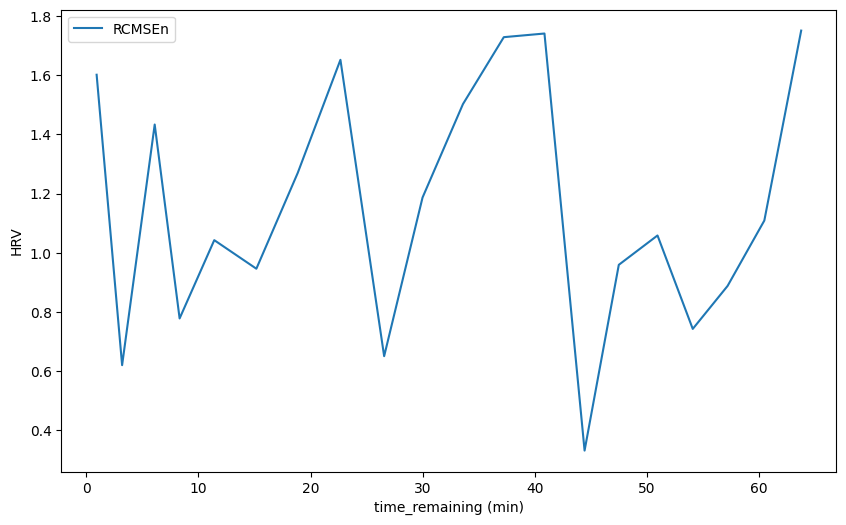

In [10]:
# time_remaining resets at each new episode; plotting all rows in one line connects
# the end of episode i to the start of episode i+1 → long diagonal "loops".
# feature_cols = ["HRV_RMSSD", "HRV_SDNN", "HRV_pNN50","HRV_DFA_alpha1","HRV_LFHF"]
feature_cols = ["HRV_RCMSEn"]
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(feature_cols)))
legend_done = {c: False for c in feature_cols}
for j, col in enumerate(feature_cols):
    for _, g in patient_df.groupby("episode_index", sort=True):
        g = g.sort_values("segment_index")
        lbl = col.removeprefix("HRV_") if not legend_done[col] else None
        plt.plot(g["time_remaining"], g[col], color=colors[j], label=lbl)
        legend_done[col] = True
plt.xlabel("time_remaining (min)")
plt.ylabel("HRV")
plt.legend()
plt.show()


In [13]:
META = {"patient", "episode_index", "segment_index", "time_remaining"}
SPEARMAN_MIN_N = 10  # minimum paired rows per episode & feature

numeric_features = [
    c
    for c in df.select_dtypes(include=[np.number]).columns
    if c not in META
]

episodes_per_patient = (
    df.groupby("patient", sort=False)["episode_index"]
    .nunique()
    .rename("n_episodes")
    .sort_values(ascending=False)
)
print("Episodes per patient (top 15):")
display(episodes_per_patient.head(15))
print(
    f"Total patients: {episodes_per_patient.shape[0]}, "
    f"total patient–episode units: {df.groupby(['patient', 'episode_index'], sort=False).ngroups}"
)

rows = []
for (patient, ep_idx), g in df.groupby(["patient", "episode_index"], sort=False):
    y = g["time_remaining"].to_numpy()
    for feat in numeric_features:
        x = g[feat].to_numpy()
        mask = np.isfinite(x) & np.isfinite(y)
        n = int(mask.sum())
        if n < SPEARMAN_MIN_N:
            continue
        rho, p = spearmanr(x[mask], y[mask])
        rows.append(
            {
                "patient": patient,
                "episode_index": ep_idx,
                "feature": feat,
                "spearman_rho": rho,
                "p_value": p,
                "n": n,
            }
        )

rho_long = pd.DataFrame(rows)
print(f"Computed {len(rho_long):,} feature–episode correlations (min n={SPEARMAN_MIN_N}).")
rho_long.describe()

Episodes per patient (top 15):


patient
record_001    4
record_006    4
record_110    4
record_028    3
record_051    3
record_025    3
record_054    3
record_035    3
record_069    2
record_026    2
record_032    2
record_031    2
record_023    2
record_055    2
record_092    2
Name: n_episodes, dtype: int64

Total patients: 118, total patient–episode units: 157


/tmp/ipykernel_1394849/1172277537.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(x[mask], y[mask])


Computed 16,255 feature–episode correlations (min n=10).


,episode_index,spearman_rho,p_value,n
count,16255.000000,16237.000000,1.623700e+04,16255.000000
mean,0.335835,-0.006628,5.994607e-02,1558.188373
std,0.660812,0.362996,1.791565e-01,957.526650
min,0.000000,-1.000000,0.000000e+00,16.000000
25%,0.000000,-0.261765,8.000278e-65,740.000000
50%,0.000000,-0.008264,1.371020e-17,1440.000000
75%,0.000000,0.243956,2.859781e-04,2261.000000
max,3.000000,1.000000,1.000000e+00,3744.000000


In [14]:
# --- Summary: how predictable is time_remaining from single features? ---

alpha = 0.05
# Bonferroni is conservative when testing many features per episode
n_tests_per_episode = len(numeric_features)
alpha_bonf = alpha / max(n_tests_per_episode, 1)

episode_level = (
    rho_long.groupby(["patient", "episode_index"], sort=False)
    .agg(
        n_features_tested=("feature", "count"),
        max_abs_rho=("spearman_rho", lambda s: np.nanmax(np.abs(s))),
        median_abs_rho=("spearman_rho", lambda s: np.nanmedian(np.abs(s))),
        sig_uncorrected=("p_value", lambda s: (s < alpha).sum()),
        sig_bonferroni=("p_value", lambda s: (s < alpha_bonf).sum()),
    )
    .reset_index()
)

print("Per patient–episode (distribution across all episodes):")
print(
    episode_level[["max_abs_rho", "median_abs_rho", "sig_uncorrected", "sig_bonferroni"]]
    .describe()
    .round(4)
    .to_string()
)

feature_summary = (
    rho_long.groupby("feature", sort=False)
    .agg(
        n_episodes=("spearman_rho", "count"),
        median_rho=("spearman_rho", "median"),
        median_abs_rho=("spearman_rho", lambda s: np.median(np.abs(s))),
        frac_pos=("spearman_rho", lambda s: (s > 0).mean()),
        frac_sig_uncorrected=("p_value", lambda s: (s < alpha).mean()),
    )
    .sort_values("median_abs_rho", ascending=False)
)

print("\nTop 15 features by median |ρ| across episodes (higher = more consistent monotonic link to time_remaining):")
display(feature_summary.head(15).round(4))

weak = (feature_summary["median_abs_rho"] < 0.1).mean()
mod = ((feature_summary["median_abs_rho"] >= 0.1) & (feature_summary["median_abs_rho"] < 0.3)).mean()
strong = (feature_summary["median_abs_rho"] >= 0.3).mean()

print(
    f"\n--- Interpretation (single-feature Spearman vs time_remaining) ---\n"
    f"- Across episodes, most HRV metrics show weak monotonic association with time_remaining: "
    f"{weak:.0%} of features have median |ρ| < 0.1, {mod:.0%} in [0.1, 0.3), {strong:.0%} ≥ 0.3.\n"
    f"- max |ρ| within an episode is often modest (see table above); time_remaining is not tightly "
    f"determined by one metric alone.\n"
    f"- Uncorrected p<0.05 counts ignore multiple testing; Bonferroni α≈{alpha_bonf:.2e} per episode "
    f"({n_tests_per_episode} tests) is stricter — use for a conservative view.\n"
    f"- Non-parametric ρ captures monotonic trends only; non-monotonic or interaction effects need "
    f"models / multivariate analysis."
)

Per patient–episode (distribution across all episodes):
       max_abs_rho  median_abs_rho  sig_uncorrected  sig_bonferroni
count     157.0000        157.0000         157.0000        157.0000
mean        0.7389          0.2795          88.8408         78.4713
std         0.1471          0.1133          12.0051         17.5870
min         0.4123          0.0761          35.0000          1.0000
25%         0.6286          0.1948          86.0000         72.0000
50%         0.7548          0.2584          92.0000         83.0000
75%         0.8532          0.3426          98.0000         91.0000
max         1.0000          0.6029         103.0000        102.0000

Top 15 features by median |ρ| across episodes (higher = more consistent monotonic link to time_remaining):


,n_episodes,median_rho,median_abs_rho,frac_pos,frac_sig_uncorrected
feature,,,,,
HRV_MedianNN,157,0.2198,0.4077,0.6943,0.9299
HRV_MeanNN,157,0.1835,0.3978,0.7006,0.9236
HRV_Prc20NN,157,0.1877,0.3929,0.6242,0.9363
HRV_Prc80NN,157,0.1860,0.3714,0.6561,0.9299
HRV_CVSD,157,-0.0150,0.3647,0.4841,0.8726
HRV_pNN50,157,-0.0970,0.3598,0.4522,0.8981
HRV_SDSD,157,-0.0406,0.3564,0.4522,0.8981
HRV_RMSSD,157,-0.0406,0.3564,0.4522,0.8981
HRV_SD1,157,-0.0406,0.3564,0.4522,0.8981



--- Interpretation (single-feature Spearman vs time_remaining) ---
- Across episodes, most HRV metrics show weak monotonic association with time_remaining: 0% of features have median |ρ| < 0.1, 70% in [0.1, 0.3), 22% ≥ 0.3.
- max |ρ| within an episode is often modest (see table above); time_remaining is not tightly determined by one metric alone.
- Uncorrected p<0.05 counts ignore multiple testing; Bonferroni α≈4.81e-04 per episode (104 tests) is stricter — use for a conservative view.
- Non-parametric ρ captures monotonic trends only; non-monotonic or interaction effects need models / multivariate analysis.


In [15]:
# --- Within-episode z-score: trajectory vs baseline, not absolute level ---
# Absolute HRV differs by patient; z-scoring within (patient, episode_index) asks whether
# deviations from that episode's mean track time_remaining.


def _zscore_group(x: pd.Series) -> pd.Series:
    sd = x.std(ddof=0)
    if sd == 0 or not np.isfinite(sd):
        return pd.Series(np.nan, index=x.index, dtype=float)
    return (x - x.mean()) / sd


Z_SUFFIX = "_z"
z_feature_cols = []
for feat in numeric_features:
    zname = f"{feat}{Z_SUFFIX}"
    df[zname] = df.groupby(["patient", "episode_index"], sort=False)[feat].transform(_zscore_group)
    z_feature_cols.append(zname)

print(
    f"Added {len(z_feature_cols)} columns (*{Z_SUFFIX}); within each (patient, episode_index) "
    "values are z-scored (NaN if the segment is constant)."
)
# Alias matching the usual RMSSD naming (same as HRV_RMSSD_z):
if "HRV_RMSSD_z" in df.columns:
    df["RMSSD_norm"] = df["HRV_RMSSD_z"]

rows_z = []
for (patient, ep_idx), g in df.groupby(["patient", "episode_index"], sort=False):
    y = g["time_remaining"].to_numpy()
    for zname in z_feature_cols:
        base_feature = zname[: -len(Z_SUFFIX)]
        x = g[zname].to_numpy()
        mask = np.isfinite(x) & np.isfinite(y)
        n = int(mask.sum())
        if n < SPEARMAN_MIN_N:
            continue
        rho, p = spearmanr(x[mask], y[mask])
        rows_z.append(
            {
                "patient": patient,
                "episode_index": ep_idx,
                "feature": base_feature,
                "spearman_rho": rho,
                "p_value": p,
                "n": n,
            }
        )

rho_long_z = pd.DataFrame(rows_z)
print(f"Within-episode z-scored Spearman: {len(rho_long_z):,} correlations.")

_alpha = alpha if "alpha" in globals() else 0.05

feature_summary_z = (
    rho_long_z.groupby("feature", sort=False)
    .agg(
        n_episodes=("spearman_rho", "count"),
        median_rho=("spearman_rho", "median"),
        median_abs_rho=("spearman_rho", lambda s: np.median(np.abs(s))),
        frac_pos=("spearman_rho", lambda s: (s > 0).mean()),
        frac_sig_uncorrected=("p_value", lambda s: (s < _alpha).mean()),
    )
    .sort_values("median_abs_rho", ascending=False)
)

print(
    "\nTop 15 features by median |ρ| on z-scored values "
    "(episode-relative trajectory vs time_remaining):"
)
display(feature_summary_z.head(15).round(4))

def _median_abs_by_feat(rdf):
    return rdf.groupby("feature", sort=False)["spearman_rho"].apply(
        lambda s: np.median(np.abs(s))
    )


raw_med_of_meds = _median_abs_by_feat(rho_long).median()
z_med_of_meds = _median_abs_by_feat(rho_long_z).median()
print(
    "\nAcross features, median of episode-level median |ρ|: "
    f"raw={raw_med_of_meds:.4f}, z-scored={z_med_of_meds:.4f}"
)

weak_z = (feature_summary_z["median_abs_rho"] < 0.1).mean()
mod_z = (
    (feature_summary_z["median_abs_rho"] >= 0.1)
    & (feature_summary_z["median_abs_rho"] < 0.3)
).mean()
strong_z = (feature_summary_z["median_abs_rho"] >= 0.3).mean()
print(
    f"\nZ-scored vs time_remaining (same |ρ| bands as raw): "
    f"{weak_z:.0%} median |ρ| < 0.1, {mod_z:.0%} in [0.1, 0.3), {strong_z:.0%} ≥ 0.3."
)


/tmp/ipykernel_1394849/4258606888.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[zname] = df.groupby(["patient", "episode_index"], sort=False)[feat].transform(_zscore_group)
/tmp/ipykernel_1394849/4258606888.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[zname] = df.groupby(["patient", "episode_index"], sort=False)[feat].transform(_zscore_group)
/tmp/ipykernel_1394849/4258606888.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

Added 104 columns (*_z); within each (patient, episode_index) values are z-scored (NaN if the segment is constant).


/tmp/ipykernel_1394849/4258606888.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(x[mask], y[mask])


Within-episode z-scored Spearman: 16,241 correlations.

Top 15 features by median |ρ| on z-scored values (episode-relative trajectory vs time_remaining):


,n_episodes,median_rho,median_abs_rho,frac_pos,frac_sig_uncorrected
feature,,,,,
HRV_MedianNN,157,0.2198,0.4077,0.6943,0.9299
HRV_MeanNN,157,0.1835,0.3978,0.7006,0.9236
HRV_Prc20NN,157,0.1877,0.3929,0.6242,0.9363
HRV_Prc80NN,157,0.1860,0.3714,0.6561,0.9299
HRV_CVSD,157,-0.0150,0.3647,0.4841,0.8726
HRV_pNN50,157,-0.0970,0.3598,0.4522,0.8981
HRV_SD1,157,-0.0406,0.3564,0.4522,0.8981
HRV_SDSD,157,-0.0406,0.3564,0.4522,0.8981
HRV_RMSSD,157,-0.0406,0.3564,0.4522,0.8981



Across features, median of episode-level median |ρ|: raw=0.2602, z-scored=0.2604

Z-scored vs time_remaining (same |ρ| bands as raw): 0% median |ρ| < 0.1, 75% in [0.1, 0.3), 22% ≥ 0.3.


In [16]:
# Benjamini–Hochberg FDR across all numeric features *within* each patient–episode.
# (Same multiplicity structure as Bonferroni per episode, but FDR control instead of FWER.)


def _drop_bh_cols(rdf: pd.DataFrame) -> pd.DataFrame:
    drop = [c for c in ("q_bh_within_episode", "sig_bh_fdr") if c in rdf.columns]
    return rdf.drop(columns=drop) if drop else rdf


def _add_bh_q_within_episode(rdf: pd.DataFrame, pcol: str = "p_value") -> pd.DataFrame:
    parts = []
    for _, g in rdf.groupby(["patient", "episode_index"], sort=False):
        p = g[pcol].to_numpy(dtype=float)
        q = np.full(len(g), np.nan, dtype=float)
        ok = np.isfinite(p)
        if ok.any():
            q[ok] = false_discovery_control(p[ok])
        parts.append(g.assign(q_bh_within_episode=q))
    return pd.concat(parts, ignore_index=True)


def _feature_bh_table(rdf: pd.DataFrame) -> pd.DataFrame:
    return (
        rdf.groupby("feature", sort=False)
        .agg(
            n_episodes=("patient", "count"),
            n_sig_bh_fdr=("sig_bh_fdr", "sum"),
        )
        .assign(frac_episodes_sig_bh=lambda t: t["n_sig_bh_fdr"] / t["n_episodes"])
        .sort_values(["frac_episodes_sig_bh", "n_sig_bh_fdr"], ascending=False)
    )


def _display_full(df):
    """Render the full DataFrame (no pandas row ellipsis)."""
    with pd.option_context("display.max_rows", None):
        display(df)


_fdr_alpha = alpha if "alpha" in globals() else 0.05

rho_long = _add_bh_q_within_episode(_drop_bh_cols(rho_long))
rho_long["sig_bh_fdr"] = rho_long["q_bh_within_episode"] <= _fdr_alpha
feat_bh_raw = _feature_bh_table(rho_long)

_m = rho_long.groupby(["patient", "episode_index"], sort=False).size()
print(
    f"=== Raw Spearman vs time_remaining: Benjamini–Hochberg ===\n"
    f"Within each patient–episode, adjust across m ≈ {int(_m.median())} feature tests "
    f"(min {int(_m.min())}, max {int(_m.max())}). "
    f"Reject H0 for that episode if q ≤ {_fdr_alpha}.\n"
)
print(
    f"Features with ≥1 episode surviving BH-FDR: {(feat_bh_raw['n_sig_bh_fdr'] >= 1).sum()} / {len(feat_bh_raw)}"
)
_display_full(feat_bh_raw[feat_bh_raw["n_sig_bh_fdr"] >= 1].round(4))

_all = feat_bh_raw[feat_bh_raw["n_sig_bh_fdr"] == feat_bh_raw["n_episodes"]]
print(
    f"\nFeatures surviving BH-FDR in every episode they appear in: {len(_all)} / {len(feat_bh_raw)}"
)
if len(_all):
    _display_full(_all.round(4))
else:
    print("(none)")

if "rho_long_z" in globals() and isinstance(rho_long_z, pd.DataFrame) and len(rho_long_z) > 0:
    rho_long_z = _add_bh_q_within_episode(_drop_bh_cols(rho_long_z))
    rho_long_z["sig_bh_fdr"] = rho_long_z["q_bh_within_episode"] <= _fdr_alpha
    feat_bh_z = _feature_bh_table(rho_long_z)
    print(
        "\n=== Within-episode z-scored Spearman (same BH-FDR per episode) ===\n"
        f"Features with ≥1 episode surviving BH-FDR: {(feat_bh_z['n_sig_bh_fdr'] >= 1).sum()} / {len(feat_bh_z)}"
    )
    _display_full(feat_bh_z[feat_bh_z["n_sig_bh_fdr"] >= 1].round(4))
    _all_z = feat_bh_z[feat_bh_z["n_sig_bh_fdr"] == feat_bh_z["n_episodes"]]
    print(
        f"\nFeatures surviving in every episode: {len(_all_z)} / {len(feat_bh_z)}"
    )
    if len(_all_z):
        _display_full(_all_z.round(4))
    else:
        print("(none)")


=== Raw Spearman vs time_remaining: Benjamini–Hochberg ===
Within each patient–episode, adjust across m ≈ 104 feature tests (min 101, max 104). Reject H0 for that episode if q ≤ 0.05.

Features with ≥1 episode surviving BH-FDR: 104 / 104


,n_episodes,n_sig_bh_fdr,frac_episodes_sig_bh
feature,,,
HRV_Prc20NN,157,146,0.9299
HRV_MedianNN,157,144,0.9172
HRV_MadNN,157,144,0.9172
HRV_Prc80NN,157,144,0.9172
HRV_MeanNN,157,143,0.9108
HRV_SDNNd,157,143,0.9108
HRV_KFD,157,143,0.9108
HRV_MinNN,157,142,0.9045
HRV_HTI,157,142,0.9045



Features surviving BH-FDR in every episode they appear in: 0 / 104
(none)

=== Within-episode z-scored Spearman (same BH-FDR per episode) ===
Features with ≥1 episode surviving BH-FDR: 104 / 104


,n_episodes,n_sig_bh_fdr,frac_episodes_sig_bh
feature,,,
HRV_Prc20NN,157,146,0.9299
HRV_MedianNN,157,144,0.9172
HRV_MadNN,157,144,0.9172
HRV_Prc80NN,157,144,0.9172
HRV_MeanNN,157,143,0.9108
HRV_SDNNd,157,143,0.9108
HRV_KFD,157,143,0.9108
HRV_MinNN,157,142,0.9045
HRV_HTI,157,142,0.9045



Features surviving in every episode: 0 / 104
(none)


## Near-AF vs. far-from-AF (binned `time_remaining`)

Segments are split by **minutes** to `time_remaining` (see `dataset_analyzer.py`: values are in minutes). **Near-AF**: `time_remaining < 5` min; **far-from-AF**: `time_remaining > 30` min; the middle band is excluded. Mann–Whitney U compares distributions per feature (nonparametric, two-sided). **Cohen’s d** uses pooled SD on raw values (near minus far). **Rank-biserial r** uses Cureton’s formula on combined ranks (same sign as d: positive ⇒ higher values in the near-AF bin). Rows are pooled across all patient–episodes, so segments are not statistically independent; treat *p*-values and FDR as exploratory.

In [18]:
# Bins in minutes (time_remaining is minutes in dataset_matrics.csv)
NEAR_AF_MAX_MIN = 5.0
FAR_AF_MIN_MIN = 30.0
MWU_MIN_N = 15  # minimum finite values per group per feature

near_mask = df["time_remaining"] < NEAR_AF_MAX_MIN
far_mask = df["time_remaining"] > FAR_AF_MIN_MIN
mid_mask = ~(near_mask | far_mask)

print(
    f"Segments: near-AF (time_remaining < {NEAR_AF_MAX_MIN} min): {near_mask.sum():,}; "
    f"far-from-AF (> {FAR_AF_MIN_MIN} min): {far_mask.sum():,}; "
    f"excluded middle: {mid_mask.sum():,}; total rows {len(df):,}"
)


def cohens_d_independent(a: np.ndarray, b: np.ndarray) -> float:
    """Standardized mean difference (a − b) / pooled SD; NaN if undefined."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    na, nb = a.size, b.size
    if na < 2 or nb < 2:
        return np.nan
    va = np.var(a, ddof=1)
    vb = np.var(b, ddof=1)
    pooled = np.sqrt(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2))
    if pooled == 0 or not np.isfinite(pooled):
        return np.nan
    return (np.mean(a) - np.mean(b)) / pooled


def rank_biserial_cureton(x: np.ndarray, y: np.ndarray) -> float:
    """Cureton rank-biserial: group x = near-AF, y = far; positive ⇒ x tends larger."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    n1, n2 = x.size, y.size
    n = n1 + n2
    if n < 2:
        return np.nan
    comb = np.concatenate([x, y])
    ranks = rankdata(comb)
    r1_mean = ranks[:n1].mean()
    return (2.0 * r1_mean - (n + 1.0)) / (n - 1.0)


rows_mwu = []
for feat in numeric_features:
    x = df.loc[near_mask, feat].to_numpy(dtype=float)
    y = df.loc[far_mask, feat].to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    y = y[np.isfinite(y)]
    if x.size < MWU_MIN_N or y.size < MWU_MIN_N:
        continue
    stat_u, p_two = mannwhitneyu(x, y, alternative="two-sided")
    rows_mwu.append(
        {
            "feature": feat,
            "n_near": int(x.size),
            "n_far": int(y.size),
            "U_near": float(stat_u),
            "p_mwu": float(p_two),
            "cohens_d_near_minus_far": cohens_d_independent(x, y),
            "rank_biserial_r": rank_biserial_cureton(x, y),
        }
    )

mwu_wide = pd.DataFrame(rows_mwu)
_m = len(mwu_wide)
mwu_wide["q_bh_features"] = (
    false_discovery_control(mwu_wide["p_mwu"].to_numpy())
    if _m
    else np.array([])
)
mwu_wide["sig_bh_fdr"] = mwu_wide["q_bh_features"] <= (
    alpha if "alpha" in globals() else 0.05
)
mwu_wide = mwu_wide.sort_values("p_mwu")

_alpha_mwu = alpha if "alpha" in globals() else 0.05
print(
    f"\nMann–Whitney U per feature (near vs far), {_m} features with ≥{MWU_MIN_N} finite values per group."
    f"\nBenjamini–Hochberg FDR across these {_m} tests (q ≤ {_alpha_mwu})."
)
print(f"Features surviving BH-FDR: {int(mwu_wide['sig_bh_fdr'].sum())} / {_m}\n")

_display_full(
    mwu_wide.assign(
        cohens_d_near_minus_far=mwu_wide["cohens_d_near_minus_far"].round(4),
        rank_biserial_r=mwu_wide["rank_biserial_r"].round(4),
        p_mwu=mwu_wide["p_mwu"].map(lambda v: f"{v:.2e}"),
        q_bh_features=mwu_wide["q_bh_features"].map(lambda v: f"{v:.2e}"),
    ).drop(columns=["sig_bh_fdr"])
)

print("\nSignificant after BH-FDR (raw table):")
_display_full(mwu_wide[mwu_wide["sig_bh_fdr"]].round(6))


Segments: near-AF (time_remaining < 5.0 min): 25,431; far-from-AF (> 30.0 min): 98,249; excluded middle: 122,987; total rows 246,667

Mann–Whitney U per feature (near vs far), 104 features with ≥15 finite values per group.
Benjamini–Hochberg FDR across these 104 tests (q ≤ 0.05).
Features surviving BH-FDR: 97 / 104



,feature,n_near,n_far,U_near,p_mwu,cohens_d_near_minus_far,rank_biserial_r,q_bh_features
0,HRV_MeanNN,25431,98249,8.877362e+08,0.00e+00,-0.5274,-0.2299,0.00e+00
1,HRV_SDNN,25431,98249,1.510794e+09,0.00e+00,0.3635,0.1663,0.00e+00
5,HRV_SDSD,25431,98249,1.490042e+09,0.00e+00,0.2788,0.1531,0.00e+00
4,HRV_RMSSD,25431,98249,1.490096e+09,0.00e+00,0.2788,0.1531,0.00e+00
6,HRV_CVNN,25431,98249,1.585838e+09,0.00e+00,0.5336,0.2140,0.00e+00
7,HRV_CVSD,25431,98249,1.555720e+09,0.00e+00,0.4504,0.1949,0.00e+00
9,HRV_MadNN,25431,98249,1.482537e+09,0.00e+00,0.2729,0.1483,0.00e+00
8,HRV_MedianNN,25431,98249,8.827693e+08,0.00e+00,-0.5497,-0.2331,0.00e+00
13,HRV_Prc20NN,25431,98249,8.750131e+08,0.00e+00,-0.5705,-0.2380,0.00e+00
14,HRV_Prc80NN,25431,98249,9.769469e+08,0.00e+00,-0.3762,-0.1732,0.00e+00



Significant after BH-FDR (raw table):


,feature,n_near,n_far,U_near,p_mwu,cohens_d_near_minus_far,rank_biserial_r,q_bh_features,sig_bh_fdr
0,HRV_MeanNN,25431,98249,8.877362e+08,0.000000,-0.527437,-0.229899,0.000000,True
1,HRV_SDNN,25431,98249,1.510794e+09,0.000000,0.363456,0.166287,0.000000,True
5,HRV_SDSD,25431,98249,1.490042e+09,0.000000,0.278782,0.153091,0.000000,True
4,HRV_RMSSD,25431,98249,1.490096e+09,0.000000,0.278794,0.153125,0.000000,True
6,HRV_CVNN,25431,98249,1.585838e+09,0.000000,0.533579,0.214005,0.000000,True
7,HRV_CVSD,25431,98249,1.555720e+09,0.000000,0.450388,0.194854,0.000000,True
9,HRV_MadNN,25431,98249,1.482537e+09,0.000000,0.272907,0.148319,0.000000,True
8,HRV_MedianNN,25431,98249,8.827693e+08,0.000000,-0.549673,-0.233058,0.000000,True
13,HRV_Prc20NN,25431,98249,8.750131e+08,0.000000,-0.570488,-0.237990,0.000000,True
14,HRV_Prc80NN,25431,98249,9.769469e+08,0.000000,-0.376185,-0.173173,0.000000,True


In [15]:
from scipy.stats import linregress

slopes = []
for (pat, ep), g in df.groupby(['patient', 'episode_index']):
    g = g.sort_values('segment_index')
    for feat in numeric_features:
        x = g['segment_index'].values
        y = g[feat].values
        mask = np.isfinite(y)
        if mask.sum() < 5:
            continue
        slope, *_ = linregress(x[mask], y[mask])
        slopes.append({
            'patient': pat, 'episode_index': ep,
            'feature': feat, 'slope': slope,
            'time_remaining_start': g['time_remaining'].iloc[0]
        })

slope_df = pd.DataFrame(slopes)
# Now correlate slope with time_remaining_start across episodes

ValueError: Cannot calculate a linear regression if all x values are identical

In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import cross_val_predict

feature_cols = [c for c in df.columns if c not in 
                ['patient', 'episode_index', 'segment_index', 'time_remaining']]

# ── VERSION 1: Within-episode ceiling ────────────────────────────────────────
within_results = []

for (pat, ep), g in df.groupby(['patient', 'episode_index']):
    g = g.sort_values('segment_index')
    X = g[feature_cols].values
    y = g['time_remaining'].values
    
    # need at least 10 segments to do 5-fold CV
    if len(g) < 10:
        continue
    
    # remove columns that are all NaN in this episode
    finite_mask = np.isfinite(X).all(axis=0)
    X = X[:, finite_mask]
    
    # fill any remaining NaNs with column mean
    col_means = np.nanmean(X, axis=0)
    X = np.where(np.isfinite(X), X, col_means)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = RidgeCV(alphas=[0.1, 1, 10, 100])
    y_pred = cross_val_predict(model, X_scaled, y, cv=5)
    
    r2 = r2_score(y, y_pred)
    
    # also compute AUC for "near AF" (time_remaining < 5 min)
    y_binary = (y < 5).astype(int)
    if y_binary.sum() > 0 and (1 - y_binary).sum() > 0:
        # lower predicted time = higher risk, so negate
        auc = roc_auc_score(y_binary, -y_pred)
    else:
        auc = np.nan
    
    within_results.append({
        'patient': pat, 'episode': ep,
        'r2': r2, 'auc': auc, 'n_segments': len(g)
    })

within_df = pd.DataFrame(within_results)
print("=== Within-episode (upper bound) ===")
print(within_df[['r2', 'auc']].describe().round(3))


# ── VERSION 2: Leave-one-patient-out ─────────────────────────────────────────
patients = df['patient'].unique()
lopo_results = []

for test_patient in patients:
    train = df[df['patient'] != test_patient]
    test  = df[df['patient'] == test_patient]
    
    X_train = train[feature_cols].values
    y_train = train['time_remaining'].values
    X_test  = test[feature_cols].values
    y_test  = test['time_remaining'].values
    
    # keep only columns that are finite in both splits
    finite_mask = (np.isfinite(X_train).all(axis=0) & 
                   np.isfinite(X_test).all(axis=0))
    X_train = X_train[:, finite_mask]
    X_test  = X_test[:, finite_mask]
    
    col_means = np.nanmean(X_train, axis=0)
    X_train = np.where(np.isfinite(X_train), X_train, col_means)
    X_test  = np.where(np.isfinite(X_test),  X_test,  col_means)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    
    model = RidgeCV(alphas=[0.1, 1, 10, 100])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    
    y_binary = (y_test < 5).astype(int)
    if y_binary.sum() > 0 and (1 - y_binary).sum() > 0:
        auc = roc_auc_score(y_binary, -y_pred)
    else:
        auc = np.nan
    
    lopo_results.append({
        'test_patient': test_patient,
        'r2': r2, 'auc': auc
    })

lopo_df = pd.DataFrame(lopo_results)
print("\n=== Leave-one-patient-out (cross-patient) ===")
print(lopo_df[['r2', 'auc']].describe().round(3))

=== Within-episode (upper bound) ===
            r2      auc
count  157.000  157.000
mean    -0.476    0.499
std      0.871    0.262
min     -3.616    0.000
25%     -0.953    0.250
50%     -0.248    0.500
75%      0.177    0.706
max      0.901    1.000

=== Leave-one-patient-out (cross-patient) ===
            r2      auc
count  118.000  118.000
mean    -0.257    0.582
std      0.491    0.240
min     -3.219    0.000
25%     -0.416    0.432
50%     -0.114    0.616
75%      0.038    0.758
max      0.378    1.000


In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import cross_val_predict

META_COLS = ["patient", "episode_index", "segment_index", "time_remaining"]
# Within an episode, *_z columns are affine functions of their raw counterparts →
# perfect collinearity if both are included; RidgeCV's SVD can fail (LinAlgError).
feature_cols = [
    c
    for c in df.columns
    if c not in META_COLS
    and not str(c).endswith("_z")
    and pd.api.types.is_numeric_dtype(df[c])
]

EPS_VAR = 1e-12


def _prepare_X(X: np.ndarray):
    """Impute NaNs, drop all-NaN / near-constant columns; return float64 design matrix."""
    X = np.asarray(X, dtype=np.float64)
    col_means = np.nanmean(X, axis=0)
    col_means = np.where(np.isfinite(col_means), col_means, 0.0)
    X = np.where(np.isfinite(X), X, col_means)
    v = np.var(X, axis=0)
    keep = np.isfinite(v) & (v > EPS_VAR)
    if keep.sum() == 0:
        return None
    return X[:, keep]


def _ridge_pipe():
    # cholesky avoids RidgeCV's SVD path; stable for dense moderate-size problems
    return make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0, solver="cholesky"),
    )


# ── VERSION 1: Within-episode (CV upper bound on generalization) ───────────
within_results = []

for (pat, ep), g in df.groupby(["patient", "episode_index"], sort=False):
    g = g.sort_values("segment_index")
    X = g[feature_cols].to_numpy(dtype=np.float64)
    y = g["time_remaining"].to_numpy(dtype=np.float64)

    if len(g) < 10:
        continue

    finite_mask = np.isfinite(X).all(axis=0)
    X = X[:, finite_mask]
    X = _prepare_X(X)
    if X is None or X.shape[1] == 0:
        continue

    model = _ridge_pipe()
    try:
        y_pred = cross_val_predict(model, X, y, cv=5)
    except np.linalg.LinAlgError:
        model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0, solver="lsqr"),
        )
        y_pred = cross_val_predict(model, X, y, cv=5)

    r2 = r2_score(y, y_pred)

    y_binary = (y < 5).astype(int)
    if y_binary.sum() > 0 and (1 - y_binary).sum() > 0:
        auc = roc_auc_score(y_binary, -y_pred)
    else:
        auc = np.nan

    within_results.append(
        {
            "patient": pat,
            "episode": ep,
            "r2": r2,
            "auc": auc,
            "n_segments": len(g),
            "n_features": X.shape[1],
        }
    )

within_df = pd.DataFrame(within_results)
print("=== Within-episode (CV; Ridge + scaled features, no *_z cols) ===")
print(within_df[["r2", "auc", "n_features"]].describe().round(3))


# ── VERSION 2: Leave-one-patient-out ─────────────────────────────────────────
patients = df["patient"].unique()
lopo_results = []

for test_patient in patients:
    train = df[df["patient"] != test_patient]
    test = df[df["patient"] == test_patient]

    X_train = train[feature_cols].to_numpy(dtype=np.float64)
    y_train = train["time_remaining"].to_numpy(dtype=np.float64)
    X_test = test[feature_cols].to_numpy(dtype=np.float64)
    y_test = test["time_remaining"].to_numpy(dtype=np.float64)

    finite_mask = np.isfinite(X_train).all(axis=0) & np.isfinite(X_test).all(axis=0)
    X_train = X_train[:, finite_mask]
    X_test = X_test[:, finite_mask]

    col_means = np.nanmean(X_train, axis=0)
    col_means = np.where(np.isfinite(col_means), col_means, 0.0)
    X_train = np.where(np.isfinite(X_train), X_train, col_means)
    X_test = np.where(np.isfinite(X_test), X_test, col_means)

    v = np.var(X_train, axis=0)
    keep = np.isfinite(v) & (v > EPS_VAR)
    if keep.sum() == 0:
        continue
    X_train = X_train[:, keep]
    X_test = X_test[:, keep]

    model = _ridge_pipe()
    try:
        model.fit(X_train, y_train)
    except np.linalg.LinAlgError:
        model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0, solver="lsqr"),
        )
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    y_binary = (y_test < 5).astype(int)
    if y_binary.sum() > 0 and (1 - y_binary).sum() > 0:
        auc = roc_auc_score(y_binary, -y_pred)
    else:
        auc = np.nan

    lopo_results.append({"test_patient": test_patient, "r2": r2, "auc": auc})

lopo_df = pd.DataFrame(lopo_results)
print("\n=== Leave-one-patient-out (cross-patient) ===")
print(lopo_df[["r2", "auc"]].describe().round(3))


=== Within-episode (CV; Ridge + scaled features, no *_z cols) ===
            r2      auc  n_features
count  157.000  157.000     157.000
mean    -1.089    0.510     102.102
std      3.335    0.262       2.020
min    -36.267    0.000      95.000
25%     -1.395    0.288     102.000
50%     -0.434    0.490     102.000
75%      0.068    0.737     103.000
max      0.877    1.000     105.000



=== Leave-one-patient-out (cross-patient) ===
            r2      auc
count  118.000  118.000
mean    -0.145    0.586
std      0.294    0.225
min     -1.437    0.000
25%     -0.280    0.452
50%     -0.096    0.618
75%      0.027    0.740
max      0.346    1.000
